In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
# Dossier racine contenant toutes les données
base_dir = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts"

# Liste pour stocker les DataFrames mensuels
dfs = []

# Boucle sur les années et mois
for year in range(2022, 2026):
    for month in range(1, 13):
        # Construit le chemin complet du fichier
        subdir = f"CAISO_LMP_Forecast_{year}_{month:02d}"
        file_path = os.path.join(base_dir, subdir, f"CAISO_LMP_Forecast_{year}_{month:02d}_processed.csv")

        # Vérifie si le fichier existe
        if os.path.exists(file_path):
            print(f"Chargement de {file_path}")
            # Lecture du CSV
            df = pd.read_csv(file_path)

            # Création de la colonne datetime
            df['timestamp'] = pd.to_datetime(dict(
                year=df['Year'], 
                month=df['Month'], 
                day=df['Day'], 
                hour=df['Hour']
            ))

            # Ajout des colonnes temporelles utiles
            df['hour'] = df['timestamp'].dt.hour
            df['day'] = df['timestamp'].dt.day
            df['month'] = df['timestamp'].dt.month
            df['day_of_week'] = df['timestamp'].dt.dayofweek

            # Sélection des colonnes pertinentes
            df = df[['timestamp', 'LMP', 'hour', 'day', 'month', 'day_of_week']]

            dfs.append(df)
        else:
            print(f"⚠️ Fichier manquant : {file_path}")

# Concatène toutes les données en un seul DataFrame
if dfs:
    data_all = pd.concat(dfs, ignore_index=True)
    data_all = data_all.sort_values('timestamp').reset_index(drop=True)
    print(f"\n✅ Total de {len(data_all)} lignes chargées à partir de {len(dfs)} fichiers.")
else:
    print("❌ Aucun fichier trouvé.")

# Exemple d'affichage
print(data_all.head())

⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_01\CAISO_LMP_Forecast_2022_01_processed.csv
⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_02\CAISO_LMP_Forecast_2022_02_processed.csv
⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_03\CAISO_LMP_Forecast_2022_03_processed.csv
⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_04\CAISO_LMP_Forecast_2022_04_processed.csv
⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_05\CAISO_LMP_Forecast_2022_05_processed.csv
⚠️ Fichier manquant : C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Fo

Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_10\CAISO_LMP_Forecast_2022_10_processed.csv
Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_11\CAISO_LMP_Forecast_2022_11_processed.csv
Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_12\CAISO_LMP_Forecast_2022_12_processed.csv
Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2023_01\CAISO_LMP_Forecast_2023_01_processed.csv
Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2023_02\CAISO_LMP_Forecast_2023_02_processed.csv
Chargement de C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2023_03\CAISO_LMP_Forecast_2023_03_proces

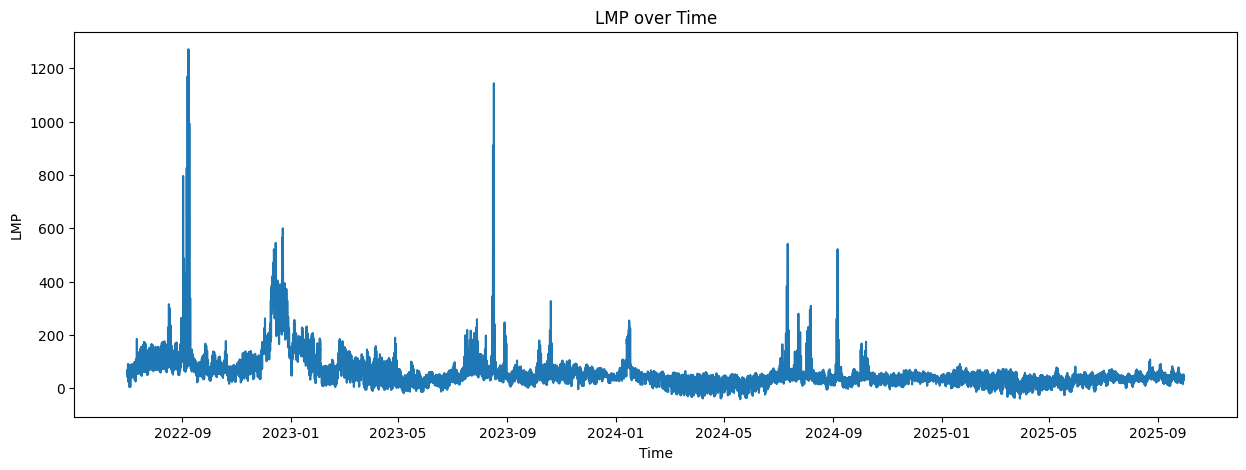

In [8]:
#i want to plot the LMP over time
plt.figure(figsize=(15,5))
plt.plot(data_all['timestamp'], data_all['LMP'])    
plt.xlabel('Time')
plt.ylabel('LMP')
plt.title('LMP over Time')
plt.show()



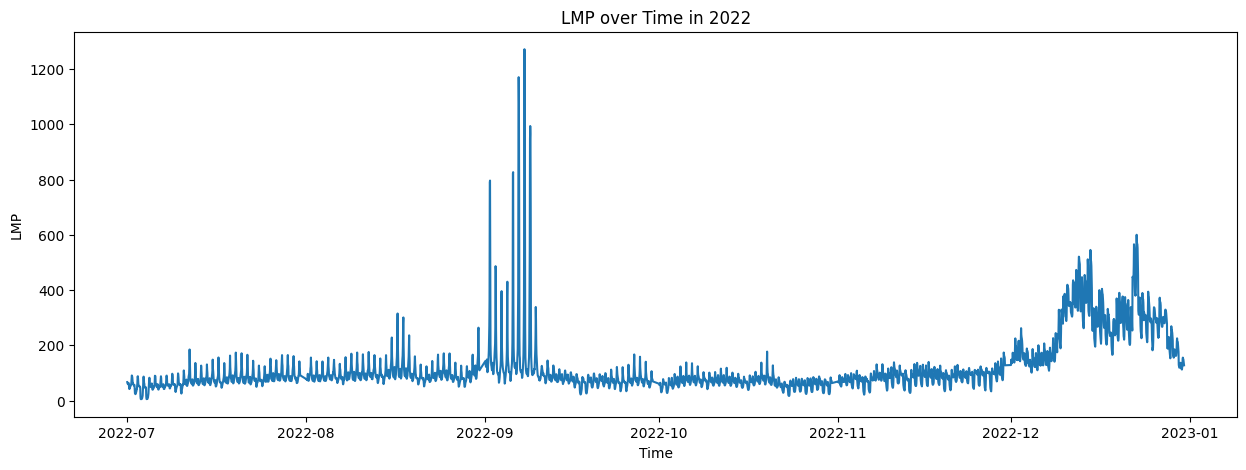

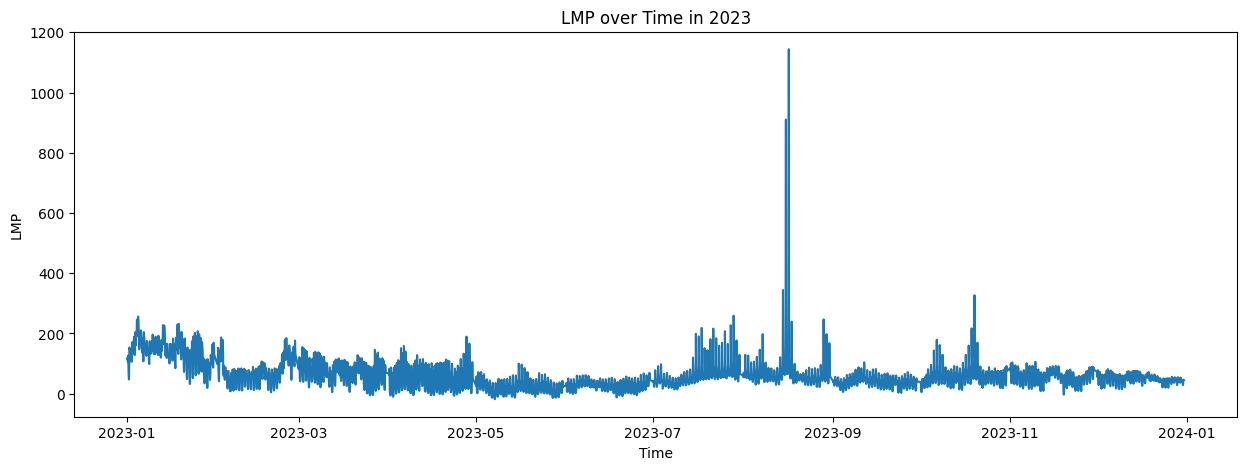

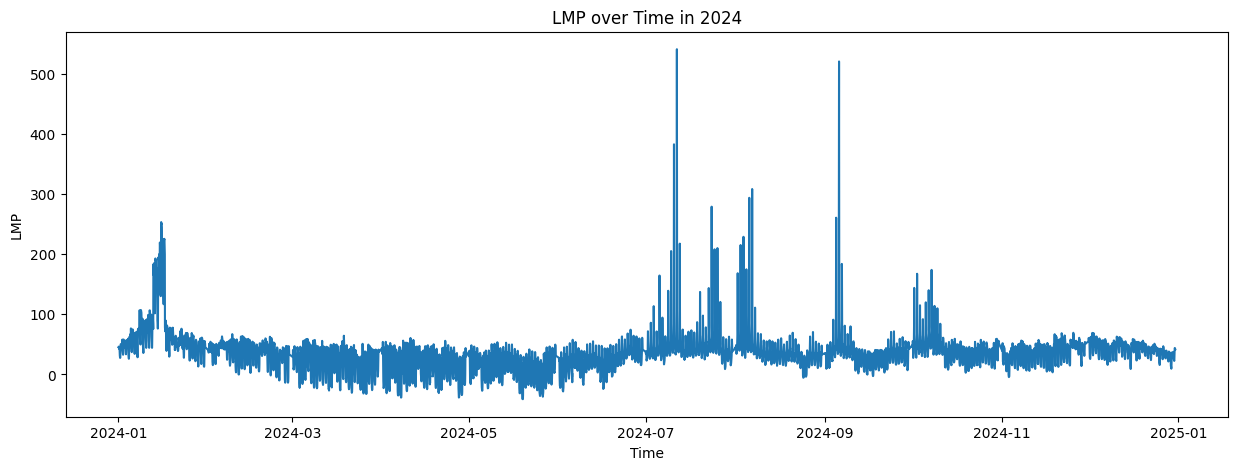

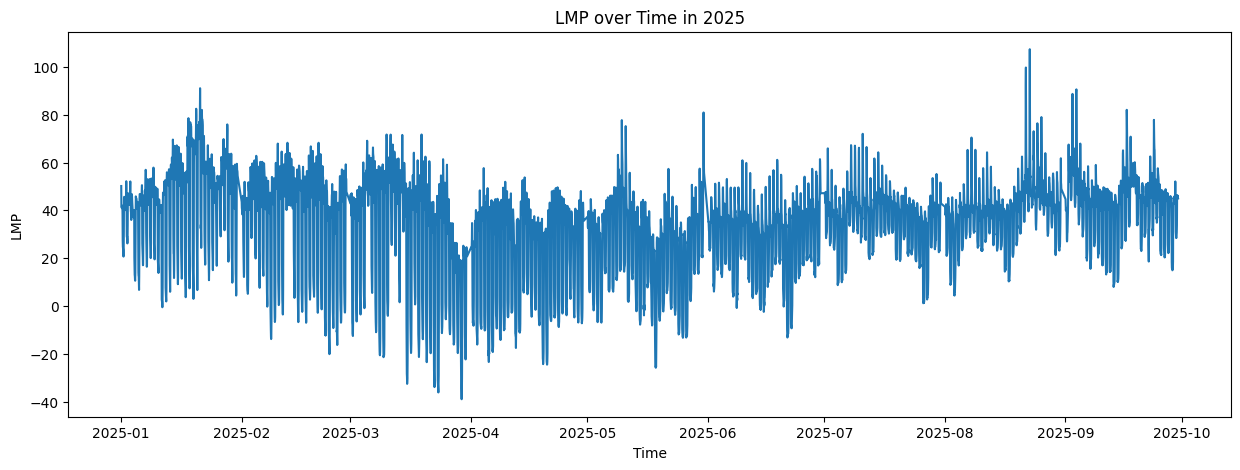

In [9]:
#i want plots that only plot the years 2022, 2023, 2024, 2025
for year in range(2022, 2026):
    plt.figure(figsize=(15,5))
    data_year = data_all[data_all['timestamp'].dt.year == year]
    plt.plot(data_year['timestamp'], data_year['LMP'])    
    plt.xlabel('Time')
    plt.ylabel('LMP')
    plt.title(f'LMP over Time in {year}')
    plt.show()

In [10]:
taille_train = 100  # nombre de points utilisés pour prédire le suivant
LMP_series = data_all['LMP'].values  # numpy array des prix

X = []
y = []

for i in range(len(LMP_series) - taille_train):
    X.append(LMP_series[i:i+taille_train])
    y.append(LMP_series[i+taille_train])

X = np.array(X)
y = np.array(y)

# Ajouter une dimension pour LSTM (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [13]:
model_naive = Sequential([
    Dense(32, activation='relu', input_shape=(taille_train,)),
    Dense(1)  # sortie : prédiction du prochain LMP
])

model_naive.compile(optimizer='adam', loss='mse')
model_naive.summary()

c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_niave = model_naive.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 198.9730 - val_loss: 25.5750
Epoch 2/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 195.3563 - val_loss: 24.3988
Epoch 3/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 173.0733 - val_loss: 24.6607
Epoch 4/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 160.5201 - val_loss: 18.4514
Epoch 5/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 159.2323 - val_loss: 18.1889
Epoch 6/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 146.0672 - val_loss: 44.7035
Epoch 7/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 155.8497 - val_loss: 21.4604
Epoch 8/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 133.3580 - val_loss: 23.8526
Epoch 9/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 151.4646 - val_loss: 18.0660
Epoch 10/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 133.9106 - val_loss: 18.2492
Epoch 11/50
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 114.1322 - val_loss: 54.9505
Epoch 12/50
687/687

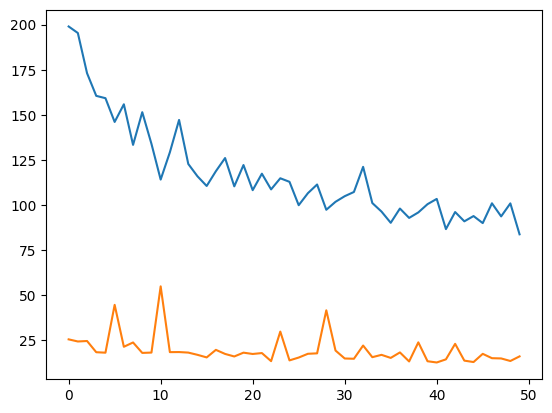

In [21]:
plt.plot(history_niave.history['loss'], label='Train Loss')
plt.plot(history_niave.history['val_loss'], label='Validation Loss')

In [24]:
y_pred_naive = model_naive.predict(X)

859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


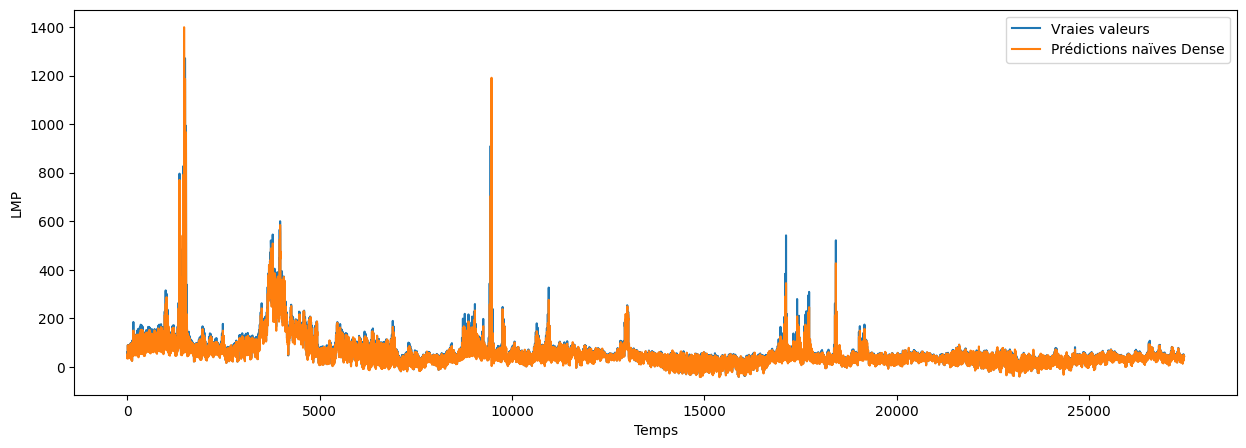

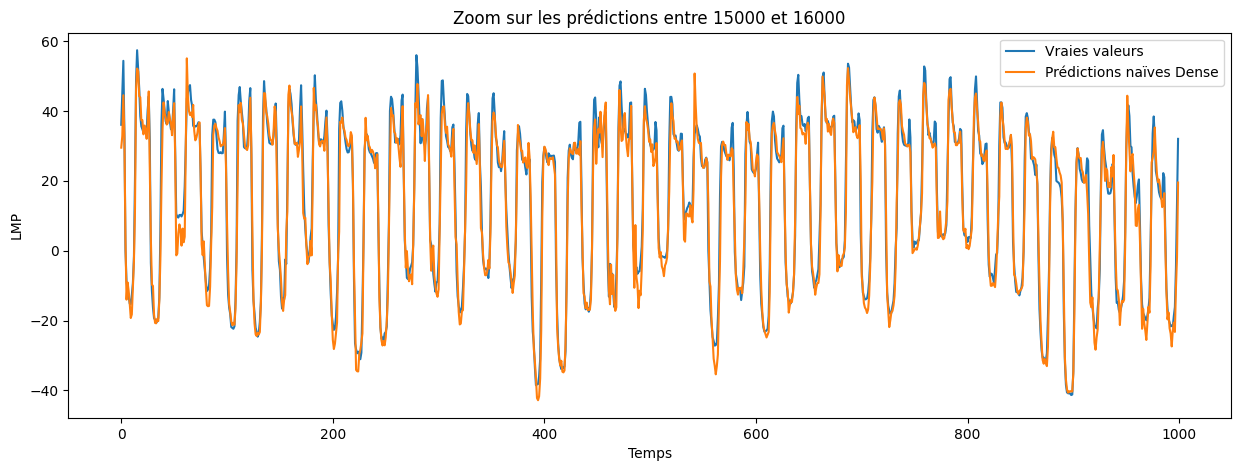

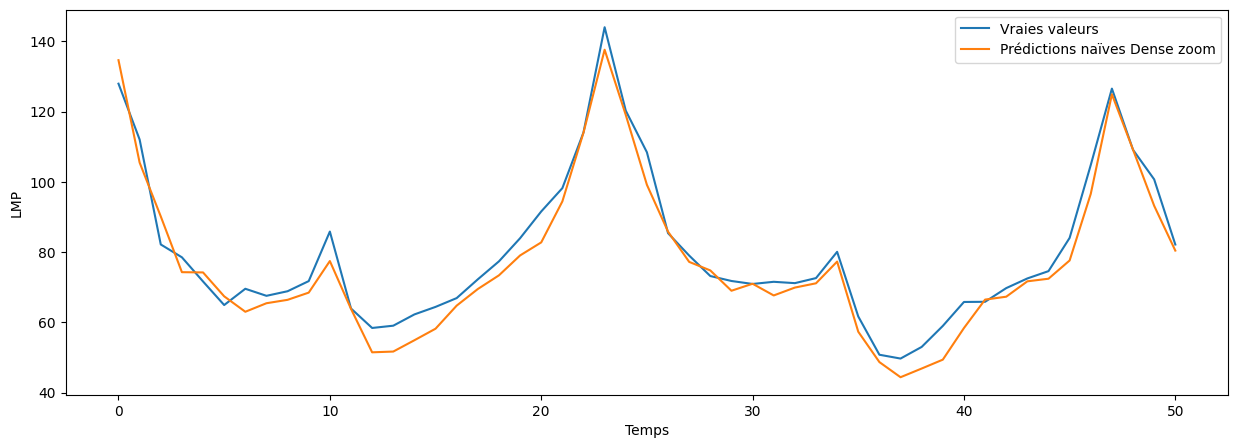

In [27]:
plt.figure(figsize=(15,5))
plt.plot(y, label='Vraies valeurs')
plt.plot(y_pred_naive, label='Prédictions naïves Dense')
plt.xlabel('Temps')
plt.ylabel('LMP')
plt.legend()


#I want a zoom in on the points beetween 15000 and 16000
plt.figure(figsize=(15,5))
plt.plot(y[15000:16000], label='Vraies valeurs')
plt.plot(y_pred_naive[15000:16000], label='Prédictions naïves Dense')
plt.xlabel('Temps')
plt.ylabel('LMP')
plt.title('Zoom sur les prédictions entre 15000 et 16000')
plt.legend()
plt.show()

y_zoom=y[400:451]
y_pred_naive_zoom=y_pred_naive[400:451]
plt.figure(figsize=(15,5))
plt.plot(y_zoom, label='Vraies valeurs')
plt.plot(y_pred_naive_zoom, label='Prédictions naïves Dense zoom')
plt.xlabel('Temps')
plt.ylabel('LMP')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step
1

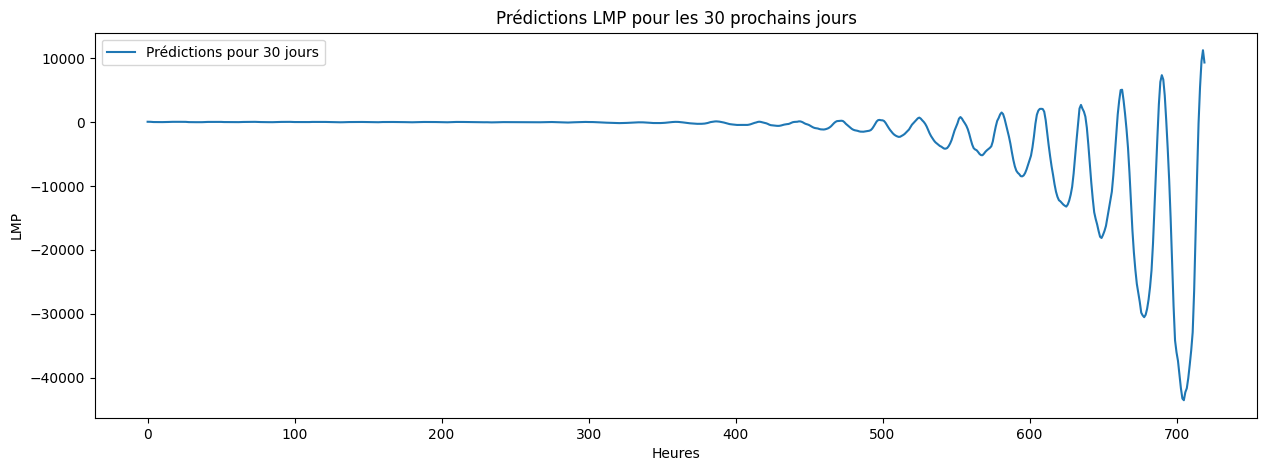

In [30]:
#take the 100 fisrt real points, and predicts for the entire month base of that
#use the model to predict the next 720 points (30 days of hourly data)
initial_input = LMP_series[:taille_train].reshape((1, taille_train, 1))
predictions = []
current_input = initial_input
for _ in range(720):
    next_pred = model_naive.predict(current_input)
    predictions.append(next_pred[0,0])
    # Update the input sequence
    current_input = np.append(current_input[:,1:,:], [[[next_pred[0,0]]]], axis=1)
plt.figure(figsize=(15,5))
plt.plot(range(720), predictions, label='Prédictions pour 30 jours')    
plt.xlabel('Heures')
plt.ylabel('LMP')
plt.title('Prédictions LMP pour les 30 prochains jours')
plt.legend()
plt.show()


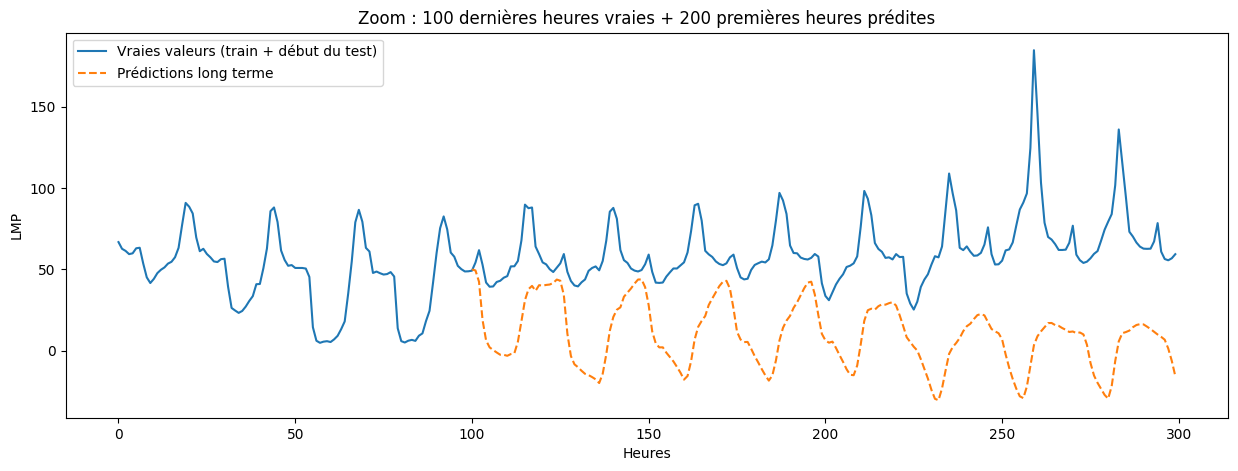

In [ ]:
# 1️⃣ Récupère les vraies valeurs du futur (jeu de test)
y_test = LMP_series[taille_train:taille_train+720]

# 2️⃣ Crée une série étendue pour afficher :
# - 100 dernières vraies valeurs d'entraînement
# - 200 premières vraies valeurs du futur
y_extended = np.concatenate((LMP_series[taille_train-100:taille_train], y_test[:200]))

# 3️⃣ Aligne les prédictions (elles couvrent le futur)
prediction_zoom = predictions[:200]

# 4️⃣ Trace
plt.figure(figsize=(15,5))
plt.plot(range(100+200), y_extended, label='Vraies valeurs (train + début du test)')
plt.plot(range(100, 100+200), prediction_zoom, label='Prédictions long terme', linestyle='--')

plt.xlabel('Heures')
plt.ylabel('LMP')
plt.title('Zoom : 100 dernières heures vraies + 200 premières heures prédites')
plt.legend()
plt.show()

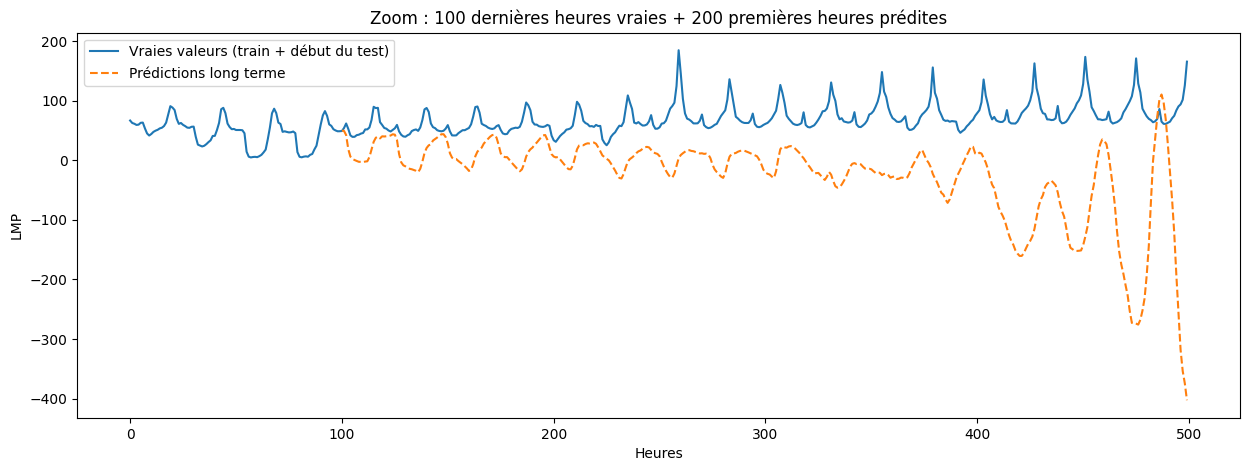

In [41]:
# 1️⃣ Récupère les vraies valeurs du futur (jeu de test)
y_test = LMP_series[taille_train:taille_train+720]

points_forecasted=400
# 2️⃣ Crée une série étendue pour afficher :
# - 100 dernières vraies valeurs d'entraînement
# - 200 premières vraies valeurs du futur
y_extended = np.concatenate((LMP_series[taille_train-100:taille_train], y_test[:points_forecasted]))

# 3️⃣ Aligne les prédictions (elles couvrent le futur)
prediction_zoom = predictions[:points_forecasted]

# 4️⃣ Trace
plt.figure(figsize=(15,5))
plt.plot(range(100+points_forecasted), y_extended, label='Vraies valeurs (train + début du test)')
plt.plot(range(100, 100+points_forecasted), prediction_zoom, label='Prédictions long terme', linestyle='--')

plt.xlabel('Heures')
plt.ylabel('LMP')
plt.title('Zoom : 100 dernières heures vraies + 200 premières heures prédites')
plt.legend()
plt.show()